In [51]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import random

### Load dataset

In [53]:
dir = "playground-series-s6e7"
train_folder = os.path.join(dir, "train.csv")
test_folder = os.path.join(dir, "test.csv")

In [54]:
train_data = pd.read_csv(train_folder, index_col="id")
test_data = pd.read_csv(test_folder, index_col="id")
train_data.shape, test_data.shape

((690088, 14), (295753, 13))

In [55]:
train_data.head()

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
id,,,,,,,,,,,,,,
0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [56]:
test_data.head()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
id,,,,,,,,,,,,,
690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other


### EDA & data preprocessing

#### data Preview

In [57]:
train_data.head()

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
id,,,,,,,,,,,,,,
0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [58]:
train_data.tail()

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
id,,,,,,,,,,,,,,
690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male
690087,at-risk,5.55,69.3,24.38,2257.0,5144.0,47.9,1.76,balanced,medium,average,moderate,yes,male


In [59]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   health_condition         690088 non-null  str    
 1   sleep_duration           614089 non-null  float64
 2   heart_rate               682255 non-null  float64
 3   bmi                      676190 non-null  float64
 4   calorie_expenditure      637235 non-null  float64
 5   step_count               676172 non-null  float64
 6   exercise_duration        683187 non-null  float64
 7   water_intake             646611 non-null  float64
 8   diet_type                683187 non-null  str    
 9   stress_level             607277 non-null  str    
 10  sleep_quality            631757 non-null  str    
 11  physical_activity_level  653467 non-null  str    
 12  smoking_alcohol          661506 non-null  str    
 13  gender                   668715 non-null  str    
dtypes: float64(7), 

In [60]:
train_data.describe(include=["str", "float64"])

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
count,690088,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000,683187,607277,631757,653467,661506,668715
unique,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,3,3,3,3
top,at-risk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,veg,medium,average,moderate,yes,male
freq,592561,NaN,NaN,NaN,NaN,NaN,NaN,NaN,231432,261819,213948,221041,223730,237756
mean,NaN,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
columns_to_drop = ["sleep_duration", "heart_rate", "bmi", "water_intake", "diet_type", "sleep_quality", "smoking_alcohol", "gender"]

train_data.drop(columns_to_drop, axis=1, inplace=True)
test_data.drop(columns_to_drop, axis=1, inplace=True)

#### Dealing with Non-Numerical data

In [62]:
category_columns = train_data.select_dtypes("str").columns
test_cat_columns = list(category_columns)
test_cat_columns.remove("health_condition")
category_columns

Index(['health_condition', 'stress_level', 'physical_activity_level'], dtype='str')

In [63]:
train_data[category_columns] = train_data[category_columns].astype(np.object_)

In [64]:
train_data["health_condition"].value_counts()/train_data["health_condition"].value_counts().sum()

health_condition
at-risk      0.858675
unhealthy    0.083647
fit          0.057678
Name: count, dtype: float64

In [65]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 6 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   health_condition         690088 non-null  object 
 1   calorie_expenditure      637235 non-null  float64
 2   step_count               676172 non-null  float64
 3   exercise_duration        683187 non-null  float64
 4   stress_level             607277 non-null  object 
 5   physical_activity_level  653467 non-null  object 
dtypes: float64(3), object(3)
memory usage: 31.6+ MB


In [66]:
train_data[category_columns].isnull().sum()

health_condition               0
stress_level               82811
physical_activity_level    36621
dtype: int64

In [67]:
mode_cat = train_data[category_columns].mode().loc[0]
mode_cat


health_condition            at-risk
stress_level                 medium
physical_activity_level    moderate
Name: 0, dtype: object

In [68]:
train_data[category_columns] = train_data[category_columns].fillna(mode_cat)
test_data[test_cat_columns] = test_data[test_cat_columns].fillna(mode_cat)

train_data[category_columns].isnull().sum()

health_condition           0
stress_level               0
physical_activity_level    0
dtype: int64

In [69]:
train_data[category_columns]

,health_condition,stress_level,physical_activity_level
id,,,
0,unhealthy,high,sedentary
1,at-risk,low,moderate
2,unhealthy,high,active
3,unhealthy,high,active
4,at-risk,medium,sedentary
...,...,...,...
690083,at-risk,high,active
690084,at-risk,medium,moderate
690085,fit,medium,active


#### Dealing with Numerical Data

In [70]:
numerical_columns = train_data.select_dtypes("float64").columns
numerical_columns

Index(['calorie_expenditure', 'step_count', 'exercise_duration'], dtype='str')

In [71]:
train_data[numerical_columns]

,calorie_expenditure,step_count,exercise_duration
id,,,
0,2174.0,1326.0,19.8
1,1966.0,9891.0,49.9
2,2688.0,14216.0,38.1
3,2630.0,7174.0,59.9
4,2560.0,6584.0,46.0
...,...,...,...
690083,2157.0,NaN,30.8
690084,2858.0,6488.0,52.4
690085,2195.0,9241.0,41.3


In [72]:
train_data[numerical_columns].isnull().sum()

calorie_expenditure    52853
step_count             13916
exercise_duration       6901
dtype: int64

In [73]:
train_data[numerical_columns].mode().loc[0]

calorie_expenditure     2201.0
step_count             12182.0
exercise_duration          0.0
Name: 0, dtype: float64

In [74]:
train_data[numerical_columns].describe()

,calorie_expenditure,step_count,exercise_duration
count,637235.000000,676172.000000,683187.000000
mean,2226.084931,8615.953050,38.751456
std,347.532098,3929.399831,14.742189
min,1200.000000,1002.000000,0.000000
25%,2053.000000,5389.000000,29.200000
50%,2241.000000,8856.000000,39.400000
75%,2456.000000,12114.000000,49.400000
max,3580.000000,14999.000000,99.800000


In [75]:
mean_fill_num = ["calorie_expenditure", "step_count"]
mode_fill_num = ["exercise_duration"]


In [76]:
mean_num = train_data[mean_fill_num].mean()
mode_num = train_data[mode_fill_num].mode().loc[0]
mode_num

exercise_duration    0.0
Name: 0, dtype: float64

In [77]:
train_data[mean_fill_num] = train_data[mean_fill_num].fillna(mean_num)
train_data[mode_fill_num] = train_data[mode_fill_num].fillna(mode_num)

test_data[mean_fill_num] = test_data[mean_fill_num].fillna(mean_num)
test_data[mode_fill_num] = test_data[mode_fill_num].fillna(mode_num)

In [78]:
train_data[numerical_columns].isnull().sum()

calorie_expenditure    0
step_count             0
exercise_duration      0
dtype: int64

In [79]:
train_data.isnull().sum()

health_condition           0
calorie_expenditure        0
step_count                 0
exercise_duration          0
stress_level               0
physical_activity_level    0
dtype: int64

#### Encode Categorical data

In [80]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 6 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   health_condition         690088 non-null  object 
 1   calorie_expenditure      690088 non-null  float64
 2   step_count               690088 non-null  float64
 3   exercise_duration        690088 non-null  float64
 4   stress_level             690088 non-null  object 
 5   physical_activity_level  690088 non-null  object 
dtypes: float64(3), object(3)
memory usage: 31.6+ MB


In [81]:
train_data.head(3)

,health_condition,calorie_expenditure,step_count,exercise_duration,stress_level,physical_activity_level
id,,,,,,
0,unhealthy,2174.0,1326.0,19.8,high,sedentary
1,at-risk,1966.0,9891.0,49.9,low,moderate
2,unhealthy,2688.0,14216.0,38.1,high,active


In [82]:
train_data.describe(include=[np.object_])

,health_condition,stress_level,physical_activity_level
count,690088,690088,690088
unique,3,3,3
top,at-risk,medium,moderate
freq,592561,344630,257662


In [83]:
encode_map = {}
for col in category_columns:
    val_c = list(train_data[col].value_counts().to_dict().keys())
    encode_map[col] = {c: i for i, c in enumerate(val_c)}
    train_data[col] = train_data[col].replace(encode_map[col])
    if col != "health_condition":
        test_data[col] = test_data[col].replace(encode_map[col])

print(encode_map)



{'health_condition': {'at-risk': 0, 'unhealthy': 1, 'fit': 2}, 'stress_level': {'medium': 0, 'high': 1, 'low': 2}, 'physical_activity_level': {'moderate': 0, 'sedentary': 1, 'active': 2}}


In [84]:
train_data[category_columns]

,health_condition,stress_level,physical_activity_level
id,,,
0,1,1,1
1,0,2,0
2,1,1,2
3,1,1,2
4,0,0,1
...,...,...,...
690083,0,1,2
690084,0,0,0
690085,2,0,2


In [85]:
train_data = train_data.astype("float64")
test_data = test_data.astype("float64")
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 6 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   health_condition         690088 non-null  float64
 1   calorie_expenditure      690088 non-null  float64
 2   step_count               690088 non-null  float64
 3   exercise_duration        690088 non-null  float64
 4   stress_level             690088 non-null  float64
 5   physical_activity_level  690088 non-null  float64
dtypes: float64(6)
memory usage: 31.6 MB


#### Normalize Numerical data

In [86]:
train_data[numerical_columns]

,calorie_expenditure,step_count,exercise_duration
id,,,
0,2174.0,1326.00000,19.8
1,1966.0,9891.00000,49.9
2,2688.0,14216.00000,38.1
3,2630.0,7174.00000,59.9
4,2560.0,6584.00000,46.0
...,...,...,...
690083,2157.0,8615.95305,30.8
690084,2858.0,6488.00000,52.4
690085,2195.0,9241.00000,41.3


In [87]:
train_data.max()

health_condition               2.0
calorie_expenditure         3580.0
step_count                 14999.0
exercise_duration             99.8
stress_level                   2.0
physical_activity_level        2.0
dtype: float64

In [88]:
train_data.min()

health_condition              0.0
calorie_expenditure        1200.0
step_count                 1002.0
exercise_duration             0.0
stress_level                  0.0
physical_activity_level       0.0
dtype: float64

In [89]:
test_data[numerical_columns] = (test_data[numerical_columns] - train_data[numerical_columns].min()) / (train_data[numerical_columns].max() - train_data[numerical_columns].min())

train_data[numerical_columns] = (train_data[numerical_columns] - train_data[numerical_columns].min()) / (train_data[numerical_columns].max() - train_data[numerical_columns].min())

train_data[numerical_columns]

,calorie_expenditure,step_count,exercise_duration
id,,,
0,0.409244,0.023148,0.198397
1,0.321849,0.635065,0.500000
2,0.625210,0.944059,0.381764
3,0.600840,0.440952,0.600200
4,0.571429,0.398800,0.460922
...,...,...,...
690083,0.402101,0.543970,0.308617
690084,0.696639,0.391941,0.525050
690085,0.418067,0.588626,0.413828


In [90]:
train_data

,health_condition,calorie_expenditure,step_count,exercise_duration,stress_level,physical_activity_level
id,,,,,,
0,1.0,0.409244,0.023148,0.198397,1.0,1.0
1,0.0,0.321849,0.635065,0.500000,2.0,0.0
2,1.0,0.625210,0.944059,0.381764,1.0,2.0
3,1.0,0.600840,0.440952,0.600200,1.0,2.0
4,0.0,0.571429,0.398800,0.460922,0.0,1.0
...,...,...,...,...,...,...
690083,0.0,0.402101,0.543970,0.308617,1.0,2.0
690084,0.0,0.696639,0.391941,0.525050,0.0,0.0
690085,2.0,0.418067,0.588626,0.413828,0.0,2.0


In [91]:
train_data = train_data.sample(frac=1).reset_index(drop=True)


In [92]:
y = train_data["health_condition"]
x = train_data[train_data.columns[1:]]
x

,calorie_expenditure,step_count,exercise_duration,stress_level,physical_activity_level
0,0.558403,0.242409,0.307615,0.0,0.0
1,0.503361,0.543970,0.427856,2.0,0.0
2,0.194538,0.331928,0.125251,2.0,1.0
3,0.431128,0.256626,0.256513,1.0,1.0
4,0.456303,0.683075,0.377756,1.0,0.0
...,...,...,...,...,...
690083,0.439916,0.786026,0.480962,2.0,2.0
690084,0.380252,0.559048,0.127255,2.0,1.0
690085,0.401261,0.392441,0.422846,0.0,1.0
690086,0.658403,0.391941,0.455912,1.0,1.0


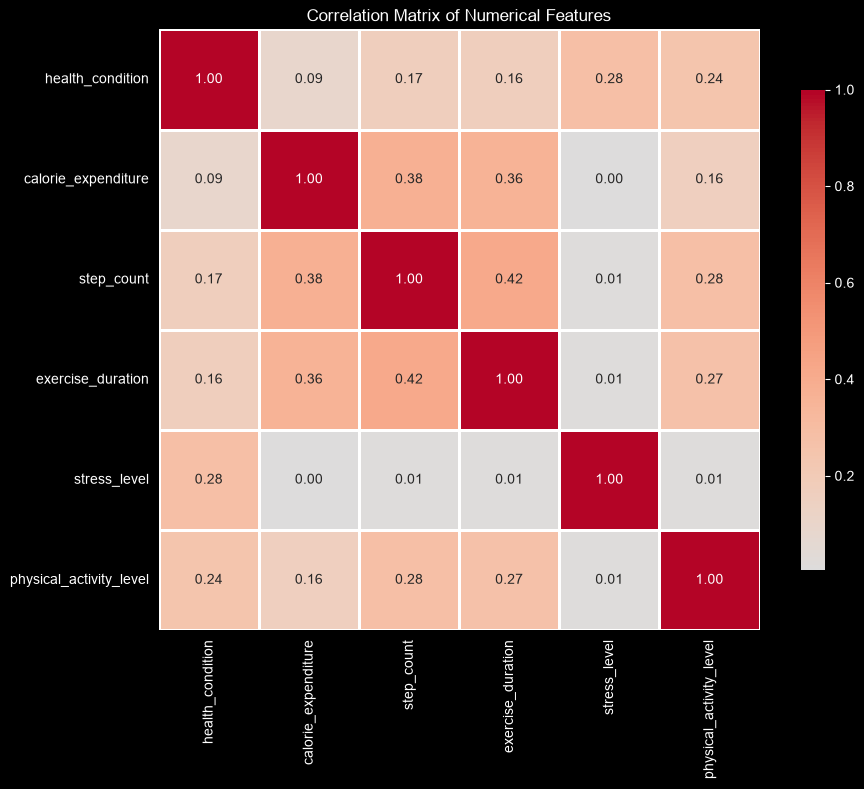


Correlation Matrix:
                         health_condition  calorie_expenditure  step_count  \
health_condition                 1.000000             0.092409    0.170503   
calorie_expenditure              0.092409             1.000000    0.380665   
step_count                       0.170503             0.380665    1.000000   
exercise_duration                0.164654             0.363699    0.418072   
stress_level                     0.282732             0.004233    0.011817   
physical_activity_level          0.243829             0.161814    0.283219   

                         exercise_duration  stress_level  \
health_condition                  0.164654      0.282732   
calorie_expenditure               0.363699      0.004233   
step_count                        0.418072      0.011817   
exercise_duration                 1.000000      0.011450   
stress_level                      0.011450      1.000000   
physical_activity_level           0.268996      0.008301   

           

In [93]:
import seaborn as sns

numerical_features = train_data
corr_matrix = numerical_features.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()
print("\nCorrelation Matrix:")
print(corr_matrix)

### Model

In [96]:
modelA = keras.Sequential([
    keras.layers.Dense(2048, activation="relu"),
    keras.layers.Dense(512, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(3, activation="softmax")
    ]
)

lr_schedule = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1)
early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

modelA.compile(
    optimizer=keras.optimizers.SGD(),
    loss=keras.metrics.sparse_categorical_crossentropy,
    metrics=["accuracy"]
)

### Training

In [97]:
epoch = 30
history = modelA.fit(x, y, batch_size=512, epochs=epoch, validation_split=0.2,
    callbacks=[lr_schedule, early_stopping])

Epoch 1/30
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accuracy: 0.8573 - loss: 0.4744 - val_accuracy: 0.8590 - val_loss: 0.4010 - learning_rate: 0.0100
Epoch 2/30
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.8624 - loss: 0.3907 - val_accuracy: 0.8691 - val_loss: 0.3731 - learning_rate: 0.0100
Epoch 3/30
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.8671 - loss: 0.3687 - val_accuracy: 0.8702 - val_loss: 0.3543 - learning_rate: 0.0100
Epoch 4/30
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 35s 33ms/step - accuracy: 0.8680 - loss: 0.3529 - val_accuracy: 0.8713 - val_loss: 0.3415 - learning_rate: 0.0100
Epoch 5/30
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 42s 39ms/step - accuracy: 0.8684 - loss: 0.3419 - val_accuracy: 0.8706 - val_loss: 0.3325 - learning_rate: 0.0100
Epoch 6/30
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 42s 39ms/step - accuracy: 0.8690 - loss: 0.3344 - val_accuracy: 0.8713 - val_loss: 0.3266 - learning_rate: 0.0100
Epoch 7/30
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 42s 39ms/step - accura

KeyboardInterrupt: 

 422/1079 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.8691 - loss: 0.3230

### Eval and Submission

In [ ]:
epoch_x = list(range(1, len(history.history["loss"])+1))
plt.plot(epoch_x, history.history["loss"], label="loss")
plt.plot(epoch_x, history.history["val_loss"], label="val loss")
plt.title("Loss vs Val Loss")
plt.legend()
plt.show()

In [ ]:

plt.plot(epoch_x, history.history["accuracy"], label="acc")
plt.plot(epoch_x, history.history["val_accuracy"], label="val acc")
plt.title("Acc vs Val Acc")
plt.legend()
plt.show()

In [ ]:
y_pred = modelA.predict(test_data)
y_pred

In [ ]:
prediction = pd.DataFrame(np.argmax(y_pred, axis=1), index=test_data.index)
prediction.columns = pd.Index(["health_condition"])
prediction = prediction.replace({i:j for j, i in encode_map["health_condition"].items()})
prediction

In [ ]:
prediction.to_csv("submissionnew1.csv")